Request data from GEE

In [4]:
import os
os.environ.setdefault("RUN_DEMO", "ON")
import src.config as c
import src.load_data as ld
import src.google_ee as gee
import src.preprocessing_general as pps
import geopandas as gpd
from pathlib import Path
import matplotlib.pyplot as plt
import utils as u
from datetime import datetime


# --------------------------
# VARIABLES
# --------------------------
YEAR_FILTER     = [2018]
CRS             = "EPSG: 4326"          # Set Coordinate Reference System (CRS) so it is uniform across all data inputs
SATELITE_IMAGES = "COPERNICUS/S2_SR_HARMONIZED"   
DATA_DIR        = os.environ.get("DATA_DIR")
RUN_ID          = f"{datetime.strftime(datetime.now(), '%Y%m%d%H%M')}_RUNNING_DEMO_{os.environ.get('RUN_DEMO')}"
RANDOM_SEED     = 42

# --------------------------
# LOAD DATA
# --------------------------
#region
# --------------------------
# VIIRS DATA
# --------------------------

viirs_dict = ld.viirs_load_pipeline(dir_name   = 'VIIRS',
                                    crs        = CRS,
                                    date_range = YEAR_FILTER)
df_viirs = viirs_dict.get('df_viirs')
print(f"{'='*80}")
print(f"🔥 VIIRS Data")
print(f"\tVIIRS data report\n\t\t{viirs_dict.get('data_report')}")
print(f"\tData Type: {type(df_viirs)}")
print(f"\t📅 Date Range: {df_viirs['date'].min()} to {df_viirs['date'].max()}")
print(df_viirs.head())

# --------------------------
# UK GRID 
# --------------------------
df_uk_grid = ld.load_uk_grid(file_name ='ukcp18-uk-land-12km.shp', 
                             crs       = CRS)
print(f"{'='*80}")
print(f"UK Grid")
print(f"Columns: \n\t{df_uk_grid.columns}")
print(f"Shape: \n\t{df_uk_grid.shape}")
print(df_uk_grid.head())

# Grids by Day
print(f"{'='*80}")
print(f"🇬🇧 UK Grid Daily")
df_daily_grid = ld.uk_grid_data_pipeline(df_uk_grid, df_viirs)
print(f"Daily UK Grid Columns: \n\t{df_daily_grid.columns}")
print(type(df_daily_grid['date'][0]))
print(f"Shape: \n\t{df_daily_grid.shape}")
print(df_daily_grid.head())

# -------------------------
# GOOGLE EE SENTINEL-2
# -------------------------
# print(f"{'='*80}")
# print(f"🛰️ GOOGLE EE SENTINEL-2")  
# # Get stored files 
# sentinel_path  = Path(DATA_DIR)/"sentinel2"
# df_sentinel = ld.sentinel_load_pipeline(sentinel_path,
#                                         df_daily_grid[df_daily_grid['date'] < '2019-01-31'],
#                                         SATELITE_IMAGES)
# print(df_sentinel.head())

# -------------------------
# FIRE WEATHER INDEX 
# -------------------------
print(f"{'='*80}")
print(f"🌡️ FIRE WEATHER INDEX")  
fwi_path    = Path(DATA_DIR)/"FWI"
df_fwi = ld.fwi_load_pipeline(fwi_path         = fwi_path, 
                              df_uk_daily_grid = df_daily_grid,
                              df_uk_grid       = df_uk_grid,
                              crs              = CRS,
                              grb_name         = 'Forest fire weather index (as defined by the Canadian Forest Service)')
print(type(df_fwi['date'].max()))
print(df_fwi.shape)
print(df_fwi.head())

#endregion




🔥 VIIRS Data
	VIIRS data report
		{'total_rows_snpp': 8790, 'total_rows_noaa': 7417}
	Data Type: <class 'geopandas.geodataframe.GeoDataFrame'>
	📅 Date Range: 2018-01-01 00:00:00 to 2018-12-31 00:00:00
    latitude  longitude  bright_ti4  scan  track       date  acq_time  \
4   53.58905   -0.60790      295.95  0.65   0.73 2018-01-01       348   
32  53.78033   -0.59153      297.74  0.39   0.59 2018-01-04       111   
35  53.39441   -1.38954      301.80  0.65   0.73 2018-01-05        52   
37  57.58453   -1.83752      304.72  0.39   0.36 2018-01-05       232   
43  51.35634   -0.47676      325.36  0.46   0.39 2018-01-05      1222   

   satellite instrument confidence  version  bright_ti5   frp daynight  type  \
4          N      VIIRS          n        2      273.02  0.85        N     0   
32         N      VIIRS          n        2      265.33  0.74        N     0   
35         N      VIIRS          n        2      272.14  1.54        N     0   
37         N      VIIRS          n      

In [2]:
# --------------------------
# PRE PROCESSING
# --------------------------
#region

import numpy as np
print(f"{'='*80}")
print(f"++ PRE PROCESSING")  

dfs_loaded = {'df_viirs'     : df_viirs,
              'df_uk_grid'   : df_uk_grid,
              'df_daily_grid': df_daily_grid,
              'df_fwi'       : df_fwi}

df_model_pre = pps.preprocessing_pipeline(dfs_loaded, RUN_ID)
df_model_pre.head()

print(df_model_pre.columns)

++ PRE PROCESSING
	✅ Succesfully saved outputs/202602231947_RUNNING_DEMO_ON/202602231947_RUNNING_DEMO_ON_LOAD_METADATA.json
	ℹ️  Removed 365 rows with grid_id == 1
	✅ Succesfully saved outputs/202602231947_RUNNING_DEMO_ON/202602231947_RUNNING_DEMO_ON_PREPROCESSING_METADATA.json
Index(['grid_id', 'x_coord_x', 'y_coord_x', 'geometry_x', 'date', 'viirs_n',
       'frp_max', 'frp_mean', 'fire_lbl', 'x_coord_y', 'y_coord_y',
       'geometry_y', 'index_right', 'fwi', 'composite_key'],
      dtype='object')


In [ ]:
import importlib
import src.preprocessing_general as pps
import src.utils as u
import pandas as pd

importlib.reload(u)
importlib.reload(pps)

RUN_ID = '0000_testrun'


def sampling_pipeline(df_preprocessed: gpd.GeoDataFrame, nofire_proximity_window_days: int):
    """
    Pipeline function to sample the data. For every fire label in the input data set, it selects integer `nofire_total_samples` of corresponding no fire values. Generates the `Y` values or `predicted` values 
    
    Generates a `bridge_composite_key_dv` which is based on the `grid_id` + `observation date` - `1 day` to then join with the `preprocessed` dataframe for the `predictor` values

    The pipeline also generates the following reporting objects:
        - A histogram showing how many observations per `year-month` with each bar showing `fire`/`nofire` by color for the `Y` variable
        - A heatmap showing which grids are included in the `Y` variable, where color intensity represents how many times a grid was sampled. The plots is an temporal aggregation of the data
        - Basic descriptive stats of the sampled values

    Args:
        df_preprocessed (df): GeoDataFrame containing all the preprocesed data with fire/nofire labels along with all the supporting data and variables

    """
    df_fire   = pps.sample_fire_obs(df_preprocessed)
    df_nofire = pps.sample_nofire_obs(df_preproc                   = df_preprocessed,
                                      df_fire                      = df_fire,
                                      nofire_proximity_window_days = 30,
                                      nofire_total_samples         = 3,
                                      random_seed                  = RANDOM_SEED)
    df_sampled = pps.sample_fire_nofire_combined(df_fire, df_nofire)

    df_all = df_sampled.merge(df_preprocessed, 
                            left_on  = 'bridge_composite_key_dv',
                            right_on = 'composite_key', 
                            how      = 'left')
    return df_all

sampling_pipeline(df_preprocessed = df_model_pre, 
                  nofire_proximity_window_days = 30, 
                  nofire_total_samples = 3,
                  random_seed = RANDOM_SEED)






columns: Index(['date_dv', 'grid_id_dv', 'fire_lbl_dv', 'bridge_composite_key_dv'], dtype='object')
Expected dimensions: (9580, 4)
--------------------------------
columns: Index(['date_dv', 'grid_id_dv', 'fire_lbl_dv', 'bridge_composite_key_dv',
       'grid_id', 'x_coord_x', 'y_coord_x', 'geometry_x', 'date', 'viirs_n',
       'frp_max', 'frp_mean', 'fire_lbl', 'x_coord_y', 'y_coord_y',
       'geometry_y', 'index_right', 'fwi', 'composite_key'],
      dtype='object')
Expected dimensions: (9580, 19)


,date_dv,grid_id_dv,fire_lbl_dv,bridge_composite_key_dv,grid_id,x_coord_x,y_coord_x,geometry_x,date,viirs_n,frp_max,frp_mean,fire_lbl,x_coord_y,y_coord_y,geometry_y,index_right,fwi,composite_key
0,2018-04-06,2,True,220180405,2.0,150000.0,30000.0,"POLYGON ((-5.57824 50.0609, -5.58629 50.16861,...",2018-04-05,0.0,0.0,0.0,False,150000.0,30000.0,POINT (150000.00058802642 29999.999329708706),181740.0,0.525391,220180405
1,2018-05-06,4,True,420180505,4.0,174000.0,30000.0,"POLYGON ((-5.2435 50.07075, -5.2508 50.1785, -...",2018-05-05,0.0,0.0,0.0,False,174000.0,30000.0,POINT (174000.00060818924 29999.999333335534),181742.0,1.492578,420180505
2,2018-10-10,4,True,420181009,4.0,174000.0,30000.0,"POLYGON ((-5.2435 50.07075, -5.2508 50.1785, -...",2018-10-09,0.0,0.0,0.0,False,174000.0,30000.0,POINT (174000.00060818924 29999.999333335534),181742.0,5.946680,420181009
3,2018-04-12,8,True,820180411,8.0,270000.0,42000.0,"POLYGON ((-3.90727 50.20835, -3.91158 50.31621...",2018-04-11,0.0,0.0,0.0,False,270000.0,42000.0,POINT (270000.0006864319 41999.99935815652),181746.0,0.006055,820180411
4,2018-07-12,9,True,920180711,9.0,174000.0,54000.0,"POLYGON ((-5.25814 50.28625, -5.26553 50.39399...",2018-07-11,0.0,0.0,0.0,False,174000.0,54000.0,POINT (174000.00061164194 53999.9993518746),180462.0,3.684570,920180711


/Users/enmanuelmoreno/Documents/Universities/Birkbeck/MSc Data Science/MSc DS Current/MSc Project/MScProjectWildFirePredict/src/preprocessing_general.py:474: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xlabel("Month")


	✅ Succesfully saved outputs/0000_testrun/0000_testrun_Monthly Observation Counts (Fire vs No Fire) [Predicted Values].pdf
	✅ Succesfully saved outputs/0000_testrun/0000_testrun_HeatMap of Sampled Grids [Predicted Values][2018-01-01 2018-12-31].pdf


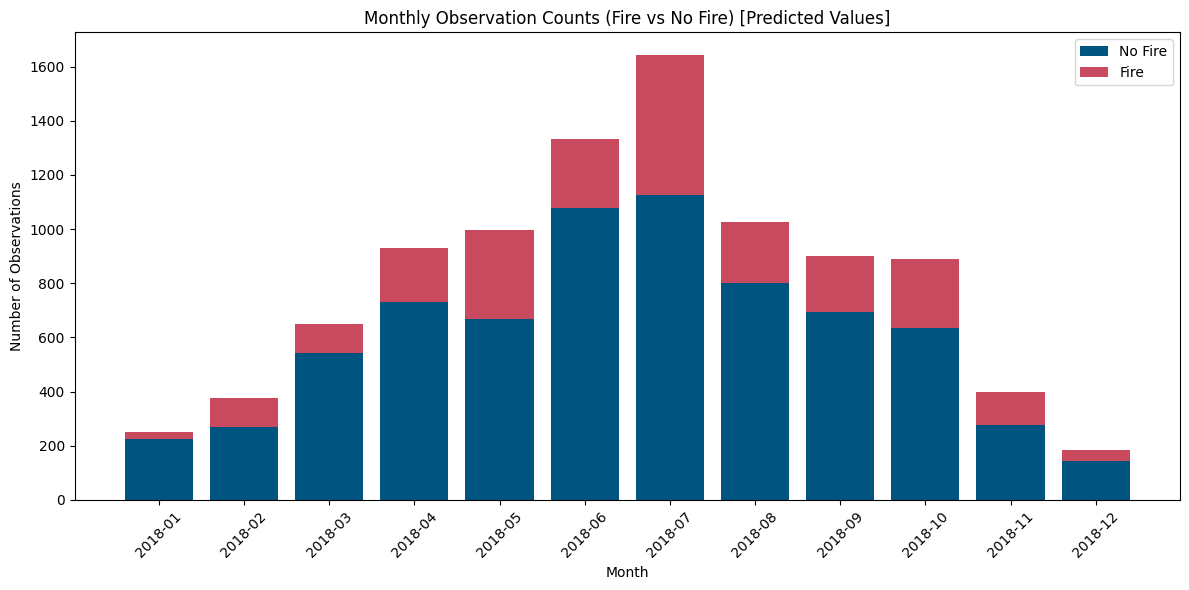

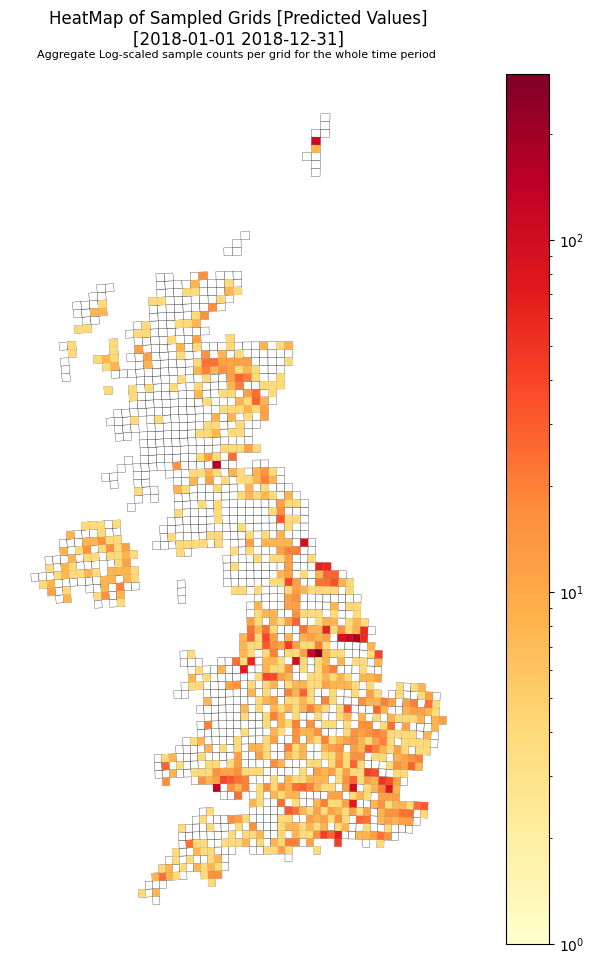

In [84]:
# Visualisation Wrapper
uk_sp_file = 'data/UKGrid/ukcp18-uk-land-12km.shp'
uk = gpd.read_file(uk_sp_file)
uk = uk.to_crs(crs=CRS)

# Generate reporting objects 
title_hist = "Monthly Observation Counts (Fire vs No Fire) [Predicted Values]"
date_min = df_all['date_dv'].min()
date_max = df_all['date_dv'].max()
title_heatmap = f"HeatMap of Sampled Grids [Predicted Values]\n[{date_min.strftime('%Y-%m-%d')} {date_max.strftime('%Y-%m-%d')}]\n"


sampled_hist    = pps.hist_sampled_variables(df_sampled = df_all, title = title_hist)
sampled_heatmap = pps.heatmap_grid_sampling(df_all, df_uk_grid, uk, title_heatmap)
u.save_plots(sampled_hist,    title_hist,    RUN_ID)
u.save_plots(sampled_heatmap, title_heatmap, RUN_ID)

In [273]:
df_all['fire_lbl_dv'].value_counts(normalize=True)

fire_lbl_dv
False    0.749791
True     0.250209
Name: proportion, dtype: Float64

In [74]:
import re
s = f"HeatMap of Sampled Grids [Predicted Values]\n[{date_min.strftime('%Y-%m-%d')} {date_max.strftime('%Y-%m-%d')}]\n"

s = re.sub(r"[\n\t]","", s)
s

'HeatMap of Sampled Grids [Predicted Values][2018-01-01 2018-12-31]'

In [34]:
gdf_plot['sample_count'].gt(0).mean()

0.4923167848699764

In [270]:
import pandas as pd
import importlib
import src.preprocessing_general as pps

importlib.reload(pps)
df_fire   = pd.DataFrame({'date_dv': pd.to_datetime(['2020-01-22','2020-03-20']),
                            'grid_id_dv': [1,1]})

df_main   = pd.DataFrame({'date': pd.date_range(start = '2020-01-19', end = '2020-01-27'),
                            'grid_id': [1]*9,
                            'fire_lbl': [False]*9})
df_main["composite_key"] = df_main["grid_id"].astype(str) + df_main["date"].dt.strftime("%Y%m%d")
df_nofire = pps.sample_nofire_obs(df_main, df_fire, 5, 2)

print("df fire")
print(df_fire)
print("df no fire")
print(df_nofire)
print("combined")
df = pd.concat([df_fire, df_nofire], ignore_index = True)
df["bridge_composite_key_dv"] = df["grid_id_dv"].astype(str) + (df["date_dv"]-pd.DateOffset(days=1)).dt.strftime("%Y%m%d")
print(df)

pps.sample_fire_nofire_combined(df_fire, df_nofire)



df fire
     date_dv  grid_id_dv
0 2020-01-22           1
1 2020-03-20           1
df no fire
     date_dv  grid_id_dv  fire_lbl_dv
7 2020-01-26           1        False
1 2020-01-20           1        False
combined
     date_dv  grid_id_dv fire_lbl_dv bridge_composite_key_dv
0 2020-01-22           1         NaN               120200121
1 2020-03-20           1         NaN               120200319
2 2020-01-26           1       False               120200125
3 2020-01-20           1       False               120200119


,date_dv,grid_id_dv,fire_lbl_dv,bridge_composite_key_dv
0,2020-01-22,1,NaN,120200121
1,2020-03-20,1,NaN,120200319
2,2020-01-26,1,False,120200125
3,2020-01-20,1,False,120200119


In [ ]:
import json
import ee
from shapely.geometry import mapping
try:
    ee.Initialize(project = "ee-enmanuelmorego")
except:
    ee.Authenticate()
    ee.Initialize(project = "ee-enmanuelmorego")
df_uk_grid.head()
# Extract polygon from Grid to pass via GEE
polygon = df_uk_grid['geometry'].iloc[0]
geojson = mapping(polygon)
grid = ee.Geometry(geojson)
print(grid.getInfo())

In [ ]:
start = '2018-06-01'
end   = '2018-06-08'
SATELITE_IMAGES = "COPERNICUS/S2_SR_HARMONIZED"   

# First fetch the images
collection = (ee.ImageCollection(SATELITE_IMAGES)
              .filterBounds(grid)
              .filterDate(start, end)
              .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 80))
              )

images_n = collection.size().getInfo()
print("Images:", images_n)


test_image = collection.first()
count = collection.select('B2').count().clip(grid)
print(count.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=grid,
    scale=30,
    maxPixels=1e13
).getInfo())
'''
      .select(['B2','B3','B4','B8'])
      .median()
      .toFloat()
      .clip(grid))

print(s2.bandNames().getInfo())
'''

composite = (collection
             .select(['B2','B3','B4','B8'])
             .median()
             .toFloat()
             .clip(grid))


In [ ]:
task = ee.batch.Export.image.toDrive(
    image=composite,
    description='test_7day_grid1',
    folder='Sentinel2',
    fileNamePrefix='grid1_7day_test_t2',
    region=grid,
    scale=30,
    crs='EPSG:32630', # Change CRS so distance in Meters is relevant
    maxPixels=1e13
)

task.start()
print(task.status())


In [ ]:
import rasterio
import os
from pathlib import Path

# Load tif file
DATA_DIR        = os.environ.get("DATA_DIR")
file = Path(DATA_DIR)/"Sentinel2"/"grid1_7day_test_t2.tif"
print(f"FILE: {file}")
with rasterio.open(file) as src:
    arr = src.read()
    print("Bands:", src.count)
    print("Shape:", src.width, src.height)
    print("CRS:", src.crs)
    print("Min:", np.nanmin(arr))
    print("Max:", np.nanmax(arr))
'''
The file basically contains this 
Band 1 (B2) → 648 × 417 matrix of numbers
Band 2 (B3) → 648 × 417 matrix of numbers
Band 3 (B4) → 648 × 417 matrix of numbers
Band 4 (B8) → 648 × 417 matrix of numbers
'''

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt


with rasterio.open(file) as src:
    arr = src.read()

# Build RGB
rgb = np.stack([arr[2], arr[1], arr[0]], axis=-1)

# Scale reflectance properly
rgb = rgb / 10000.0
rgb = np.clip(rgb, 0, 1)

plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.axis("off")
plt.title("Sentinel-2 RGB Composite")
plt.show()


In [ ]:
import geopandas as gpd
import rasterio
from shapely.geometry import box



with rasterio.open(file) as src:
    bounds = src.bounds
    crs = src.crs

# Create bounding box polygon
bbox_geom = box(bounds.left, bounds.bottom,
                bounds.right, bounds.top)

bbox = gpd.GeoDataFrame(
    geometry=[bbox_geom],
    crs=crs
)

# Reproject to WGS84 for web display
bbox = bbox.to_crs(4326)

# Interactive map
m = bbox.explore(color="red")
m


In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.warp import transform_bounds



with rasterio.open(file) as src:
    arr = src.read()
    bounds = src.bounds
    crs = src.crs

# Convert bounds to lat/lon (WGS84)
bounds_4326 = transform_bounds(crs, "EPSG:4326",
                               bounds.left, bounds.bottom,
                               bounds.right, bounds.top)

# Build RGB
rgb = np.stack([arr[2], arr[1], arr[0]], axis=-1)
rgb = rgb / 10000.0
rgb = np.clip(rgb, 0, 1)

plt.figure(figsize=(6,6))
plt.imshow(rgb,
           extent=[bounds_4326[0], bounds_4326[2],
                   bounds_4326[1], bounds_4326[3]])
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Sentinel-2 RGB (Georeferenced)")
plt.show()


Resize the files to save memory

In [ ]:
import rasterio
import numpy as np
import cv2  # pip install opencv-python

DATA_DIR        = os.environ.get("DATA_DIR")
file = Path(DATA_DIR)/"Sentinel2"/"grid1_7day_test_t2.tif"

with rasterio.open(file) as src:
    arr = src.read()

img = np.stack(arr, axis=-1) / 10000.0
img = cv2.resize(img, (256, 256))

np.save("sample_001.npy", img)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

img_resized = np.load("sample_001.npy")

# RGB = B4, B3, B2
rgb = img_resized[:, :, [2, 1, 0]]

plt.figure(figsize=(5,5))
plt.imshow(np.clip(rgb, 0, 1))
plt.axis("off")
plt.title("Resized Sentinel RGB")
plt.show()


## Sampling Method

In [ ]:
import pandas as pd

df_viirs_test = {"grid_id": [1,1,1,1,2,2,2,2],
                 "date": pd.to_datetime(["2020-01-20",
                                        "2020-02-15",
                                        "2020-02-20",
                                        "2020-02-01",
                                        "2020-01-20",
                                        "2020-01-01",
                                        "2020-03-15",
                                        "2020-04-04"]),
                 "fire_lbl": [1] * 8}

df_viirs_test = pd.DataFrame(df_viirs_test)
df_viirs_test

In [ ]:

nonfire_days = set()
df_nonfire = pd.DataFrame()
sampling_report = []
for _, r in df_fire[df_fire['fire_lbl'] == 1].iterrows():

    # Extract date
    date = r['date']
    # Create fire grid id to see which values mapped to which fire grids
    row_group_id = f"{date.strftime('%Y%m%d')}_{r['grid_id']}"
    # Extract values for mapping report
    row = r[['date','grid_id','fire_lbl']].copy()
    row['fire_grid_id'] = row_group_id
    sampling_report.append(row)

    df_sampling_report = pd.concat([df_sampling_report, row], ignore_index = True)
    try:
        nonfire_sample = df_nofire[(
                                    (
                                        (df_nofire['date'] >= (date - pd.DateOffset(days=30))) |
                                        (df_nofire['date'] <= (date + pd.DateOffset(days=7)))
                                     ) and
                                     (
                                         df_nofire['date'] not in fire_dates
                                    ) and
                                    # Ensure this is not a value that we have already sampled
                                    (
                                        df_nofire[['date', 'id']] not in df_nonfire[['date', 'id']]
                                    )
                                   )]
        for i_inner, r_inner in nonfire_sample.iterrows():
              day_nofire = r_inner['date']
              nonfire_days.update(pd.date_range(start = (day_nofire - pd.Timedelta(days=7)), end = day_nofire))
              if len(nonfire_days.intersection(fire_dates) > 0):
                   next
              nofire_row =  r_inner[['date','grid_id','fire_lbl']].copy()
              nofire_row['fire_grid_id'] = row_group_id
              sampling_report.append(row)
            
    except ValueError:
        print(f"No Non-Fire samples available for fire label on {row}")
 
df_sampling_report = pd.DataFrame(sampling_report)
df_sampling_report
    
pd.to_csv()

In [179]:
import pandas as pd
df_preprocessed = pd.read_csv('test_file.csv')

In [38]:
df_model_pre.columns

Index(['grid_id', 'x_coord_x', 'y_coord_x', 'geometry_x', 'date', 'viirs_n',
       'frp_max', 'frp_mean', 'fire_lbl', 'x_coord_y', 'y_coord_y',
       'geometry_y', 'index_right', 'fwi', 'composite_key'],
      dtype='object')

In [ ]:

import importlib
import src.preprocessing_general as pps

importlib.reload(pps)

df_values                  = df_model_pre
df_fire_obs                = pps.sample_fire_values(df_values, 7)
sampled_set                = set(df_fire_obs['composite_key'])
df_nofire_obs_candidates   = pps.sample_nofire_candidates(df_values, 30)
dict_nofire_obs            = pps.sample_nofire_values(no_fire_per_fire_obs = 3, candidate_dict = df_nofire_obs_candidates, window_size = 7, sampled_set = sampled_set)
sampling_report_df         = pd.DataFrame(dict_nofire_obs['sampling_report'])
df_sampled                 = pd.concat([df_fire_obs, dict_nofire_obs['no_fire_df']])
df_joined                  = pd.merge(df_sampled, df_model_pre, how = "left", on = "composite_key")

df_joined_cleaned = df_joined[df_joined['date_x'] == df_joined['date_y']].copy()
df_joined_cleaned['date'] = df_joined_cleaned['date_x']
df_joined_cleaned.drop(['date_x', 'date_y'], axis = 1, inplace = True)
# 


In [214]:
# Clean the joined df 
df_joined_cleaned = df_joined[df_joined['date_x'] == df_joined['date_y']].copy()
df_joined_cleaned['date'] = df_joined_cleaned['date_x']
df_joined_cleaned.drop(['date_x', 'date_y'], axis = 1, inplace = True)

print(df_joined_cleaned['date'].min())
print(df_joined_cleaned['date'].max())
print(df_joined_cleaned.columns)

2018-01-01 00:00:00
2018-12-31 00:00:00
Index(['composite_key', 'grid_id_x', 'grid_id_y', 'x_coord_x', 'y_coord_x',
       'geometry_x', 'viirs_n', 'frp_max', 'frp_mean', 'fire_lbl', 'x_coord_y',
       'y_coord_y', 'geometry_y', 'index_right', 'fwi', 'date'],
      dtype='object')


In [217]:
df_joined_cleaned['fire_lbl'].value_counts(normalize=True)

fire_lbl
False    0.958349
True     0.041651
Name: proportion, dtype: Float64

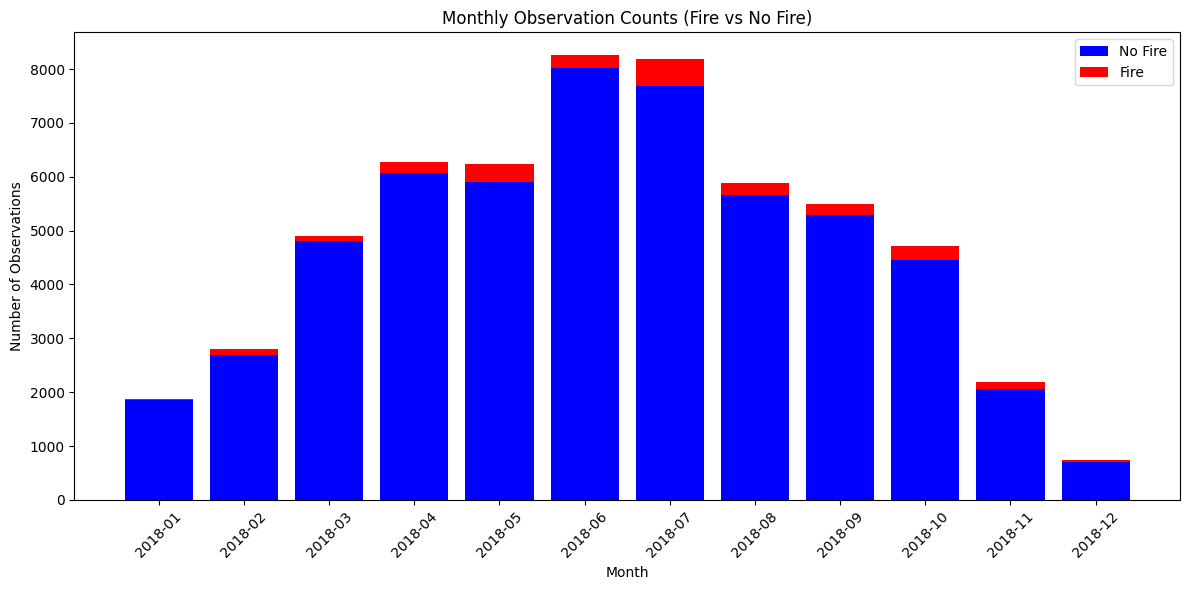

In [215]:
import pandas as pd
import matplotlib.pyplot as plt


# df_joined_cleaned = pd.DataFrame({'date': pd.to_datetime(['2020-01-01','2020-01-02',
#                                                         '2020-04-01','2020-04-02',
#                                                         '2020-12-01','2020-12-02']),
#                                     'fire_lbl': [True, False,True, False,True, False]})
# Create year-month column
df_joined_cleaned['year_month'] = df_joined_cleaned['date'].dt.to_period('M')

# Count observations per month split by fire label
monthly_counts = (
    df_joined_cleaned
        .groupby(['year_month', 'fire_lbl'])
        .size()
        .unstack(fill_value=0)
        .sort_index()
)

# Make sure both columns exist
monthly_counts = monthly_counts.reindex(columns=[False, True], fill_value=0)

# Convert PeriodIndex to string for plotting
months = monthly_counts.index.astype(str)

plt.figure(figsize=(12,6))

plt.bar(months, monthly_counts[False], label='No Fire', color='blue')
plt.bar(
    months,
    monthly_counts[True],
    bottom=monthly_counts[False],
    label='Fire',
    color='red'
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Number of Observations")
plt.title("Monthly Observation Counts (Fire vs No Fire)")
plt.legend()

plt.tight_layout()
plt.show()

In [149]:

import importlib
import src.preprocessing_general as pps

importlib.reload(pps)
df_test = {
    "grid_id": [
        1,                  # Fire
        1, 1, 1,            # Multiple valid candidates
        1,                  # Outside window (exclude)
        2,                   # Different grid (exclude)
        3,
        3],
    "date": pd.to_datetime([
        "2020-01-15",       # 🔥 Fire label

        "2020-01-10",       # ✅ Candidate 1 (within 30 days)
        "2020-01-20",       # ✅ Candidate 2
        "2020-02-05",       # ✅ Candidate 3

        "2020-04-01",       # ❌ Outside 30-day window
        "2020-01-18",        # ❌ Different grid
        "2020-06-01",
        "2020-05-29"
    ]),
    "fire_lbl": [
        True,
        False, False, False,
        False,
        False,
        True, 
        False
    ]
}

df_test = pd.DataFrame(df_test)

df_test["composite_key"] = (
    df_test["grid_id"].astype(str) +
    df_test["date"].dt.strftime("%Y%m%d")
)

df_values = df_test
df_fire_obs              = pps.sample_fire_values(df_values, 7)
sampled_set              = set(df_fire_obs['composite_key'])
df_nofire_obs_candidates = pps.sample_nofire_candidates(df_values, 30)
df_nofire_obs            = pps.sample_nofire_values(3, df_nofire_obs_candidates, window_size = 7, sampled_set = sampled_set)

df_nofire_obs_candidates.get('120200115')


,grid_id,date,fire_lbl,composite_key
1,1,2020-01-10,False,120200110
2,1,2020-01-20,False,120200120
3,1,2020-02-05,False,120200205


In [189]:
df_model_pre['date'].min()
df_model_pre['grid_id'].min()

0

In [190]:
df = pd.DataFrame({"grid_id": [2,2,2,2,2],
                    "date": pd.to_datetime(["2018-01-10", "2018-01-01","2018-01-25","2018-01-30","2018-02-05"]),
                    "fire_lbl": [True, False,False,False,False]})
df["composite_key"] = df["grid_id"].astype(str) + df["date"].dt.strftime("%Y%m%d")
print("DataFrame")
print(df)

# Fire protected set
df_fire = pps.sample_fire_values(df, window_size=2)
print("\n\nFire data set")
print(df_fire)

sampled_set = set(df_fire["composite_key"])
print("\n\nSampled Set, expect only 3 values as its a set of the composite key values fire")
print(sampled_set)

candidate_dict = pps.sample_nofire_candidates(df, 30)
print("\n\nCandidate dict: expect key 120200110 and value just 120200125 ")
print(candidate_dict)

result = pps.sample_nofire_values(no_fire_per_fire_obs=2,
                                    candidate_dict=candidate_dict,
                                    window_size=2,
                                    sampled_set=sampled_set)
print("\n\nResults")
print(result)

combined = pd.concat([df_fire, result['no_fire_df']], ignore_index = True)
df_sampled = pd.merge(combined, df_model_pre, how = "left", on = "composite_key")

print("/n/nCombined df")
print(df_sampled)





DataFrame
   grid_id       date  fire_lbl composite_key
0        2 2018-01-10      True     220180110
1        2 2018-01-01     False     220180101
2        2 2018-01-25     False     220180125
3        2 2018-01-30     False     220180130
4        2 2018-02-05     False     220180205


Fire data set
  composite_key       date  grid_id
0     220180108 2018-01-08        2
1     220180109 2018-01-09        2
2     220180110 2018-01-10        2


Sampled Set, expect only 3 values as its a set of the composite key values fire
{'220180109', '220180108', '220180110'}


Candidate dict: expect key 120200110 and value just 120200125 
{'220180110':    grid_id       date  fire_lbl composite_key
1        2 2018-01-01     False     220180101
2        2 2018-01-25     False     220180125
3        2 2018-01-30     False     220180130
4        2 2018-02-05     False     220180205}


Results
{'no_fire_df':   composite_key       date  grid_id
0     220171230 2017-12-30        2
1     220171231 2017-12-3